In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [8]:
a=[i for i in range(1,101)]
b=[i**7 for i in range(1,101)]

<Axes: >

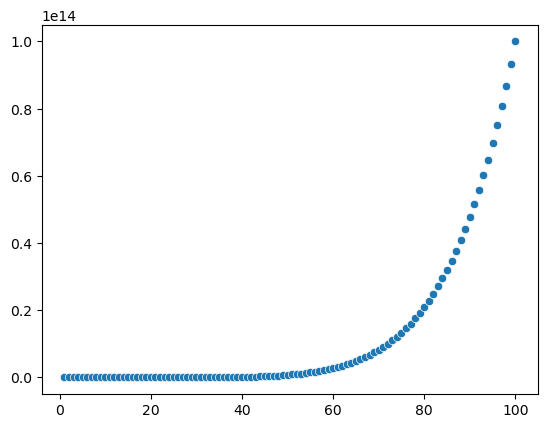

In [9]:
sns.scatterplot(x=a,y=b)

In [10]:
df=pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [11]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
# null and duplicate check

In [13]:
df.isnull().sum() # no null

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [14]:
df.duplicated().sum() # no duplicates

np.int64(0)

In [ ]:
# statistical distribution check for outlier and skewness processing
   

In [15]:
df.describe()
# +ve skewness - in newspaper

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


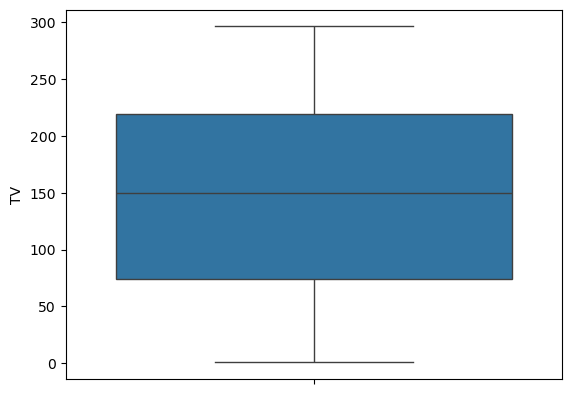

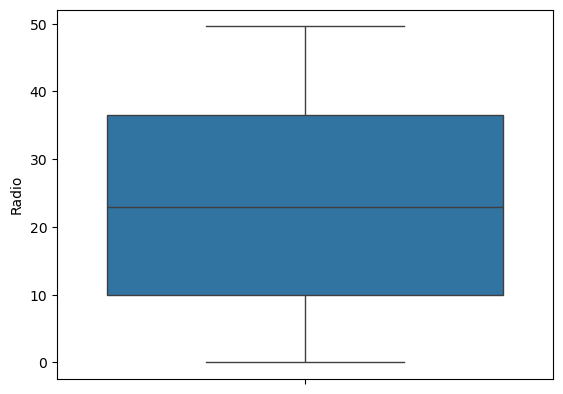

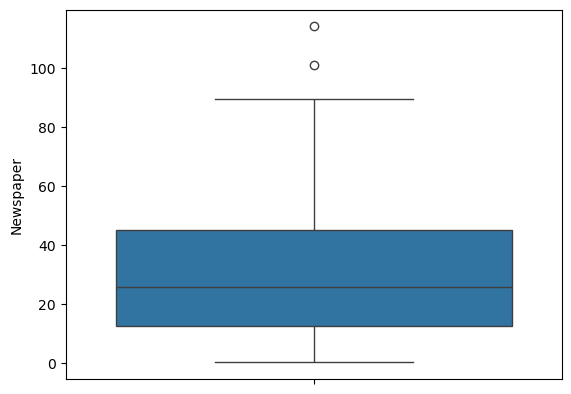

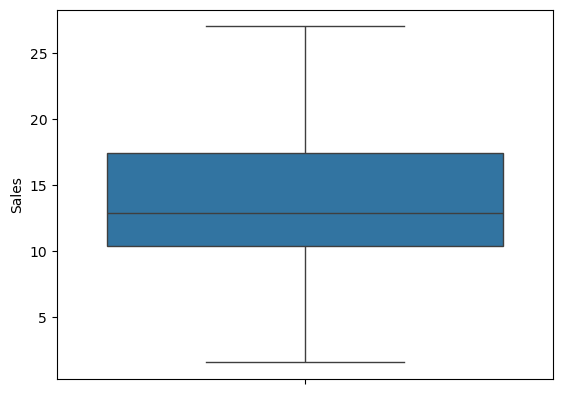

In [16]:
n_c=df.select_dtypes("float").columns
for i in n_c:
    sns.boxplot(df[i])
    plt.show()
# outlier in newspaper

In [17]:
def replacing_outliers(d):
    n=["TV","Radio","Newspaper"]
    for i in n:
        q1=d[i].quantile(0.25)
        q3=d[i].quantile(0.75)
        iqr=q3-q1
        lw=q1-1.5*iqr
        uw=q3+1.5*iqr
        d[i]=d[i].apply(lambda x:min(max(x,lw),uw))
    return d

In [18]:
replacing_outliers(df)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


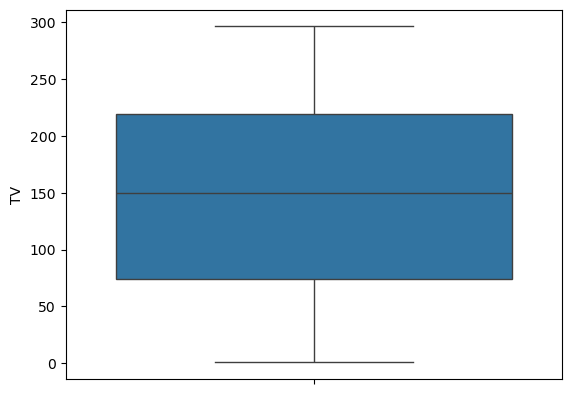

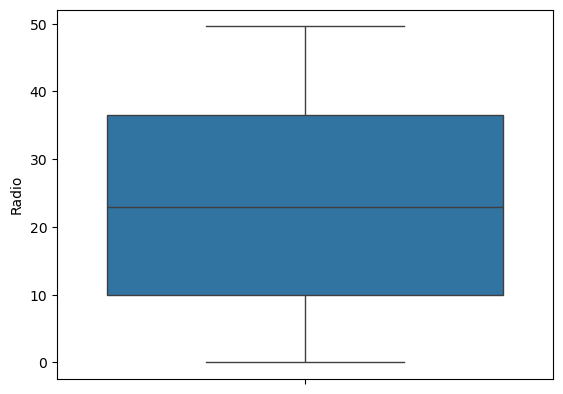

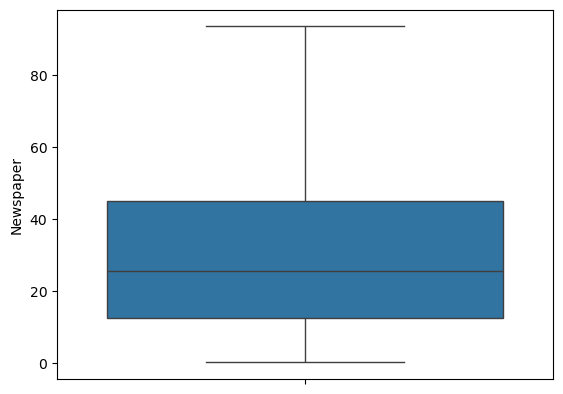

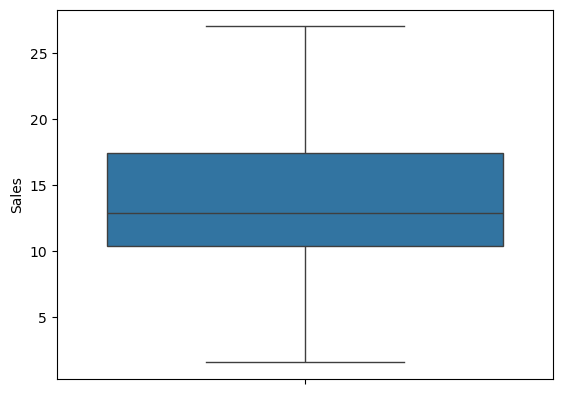

In [19]:
for i in n_c:
    sns.boxplot(df[i])
    plt.show()

In [22]:
# skewness check
from scipy.stats import skew
for i in n_c:
    print(f"{i} : {skew(df[i])}")
# Newspaper : 0.7441941750543234

TV : -0.06932836662244649
Radio : 0.0934668451108453
Newspaper : 0.7441941750543234
Sales : 0.4045082487061191


In [24]:
len(df[df["Newspaper"]<0])
# no negative value in newspaper

0

In [27]:
df[n_c].corr()["Sales"].sort_values()
# Newsapaper correlation is not high with the target

Newspaper    0.231432
Radio        0.576223
TV           0.782224
Sales        1.000000
Name: Sales, dtype: float64

<Axes: xlabel='Newspaper', ylabel='Density'>

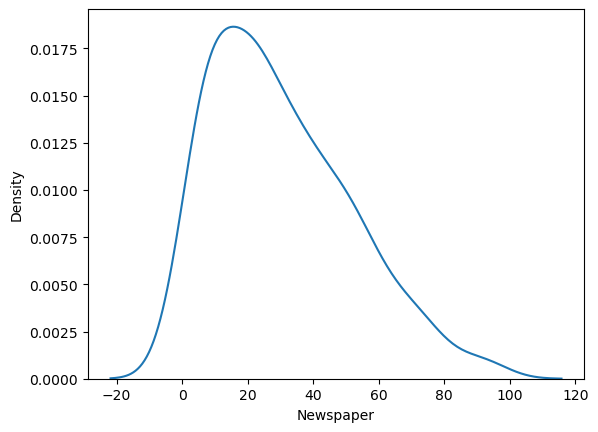

In [28]:
sns.kdeplot(df["Newspaper"])

<Axes: xlabel='Newspaper', ylabel='Density'>

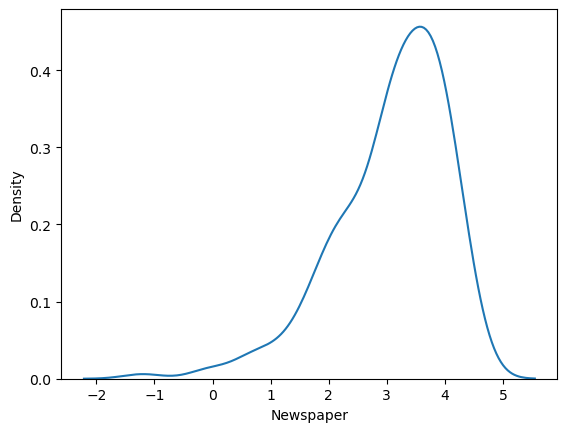

In [29]:
sns.kdeplot(np.log(df["Newspaper"]))

<Axes: xlabel='Newspaper', ylabel='Density'>

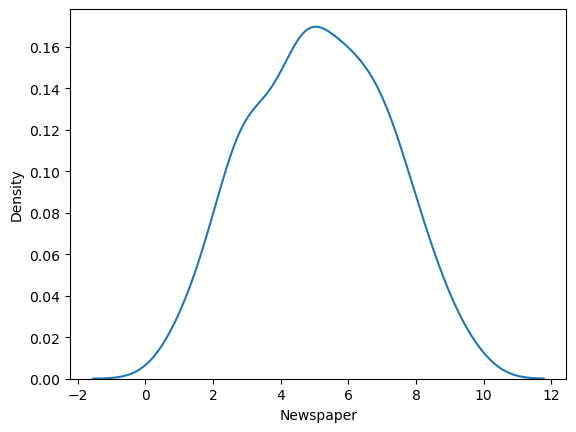

In [30]:
sns.kdeplot(np.sqrt(df["Newspaper"]))

In [31]:
df["Newspaper"]=np.sqrt(df["Newspaper"])

In [32]:
skew(df["Newspaper"])

np.float64(0.012043905982932887)

In [33]:
# object encoding
# no object type column present.

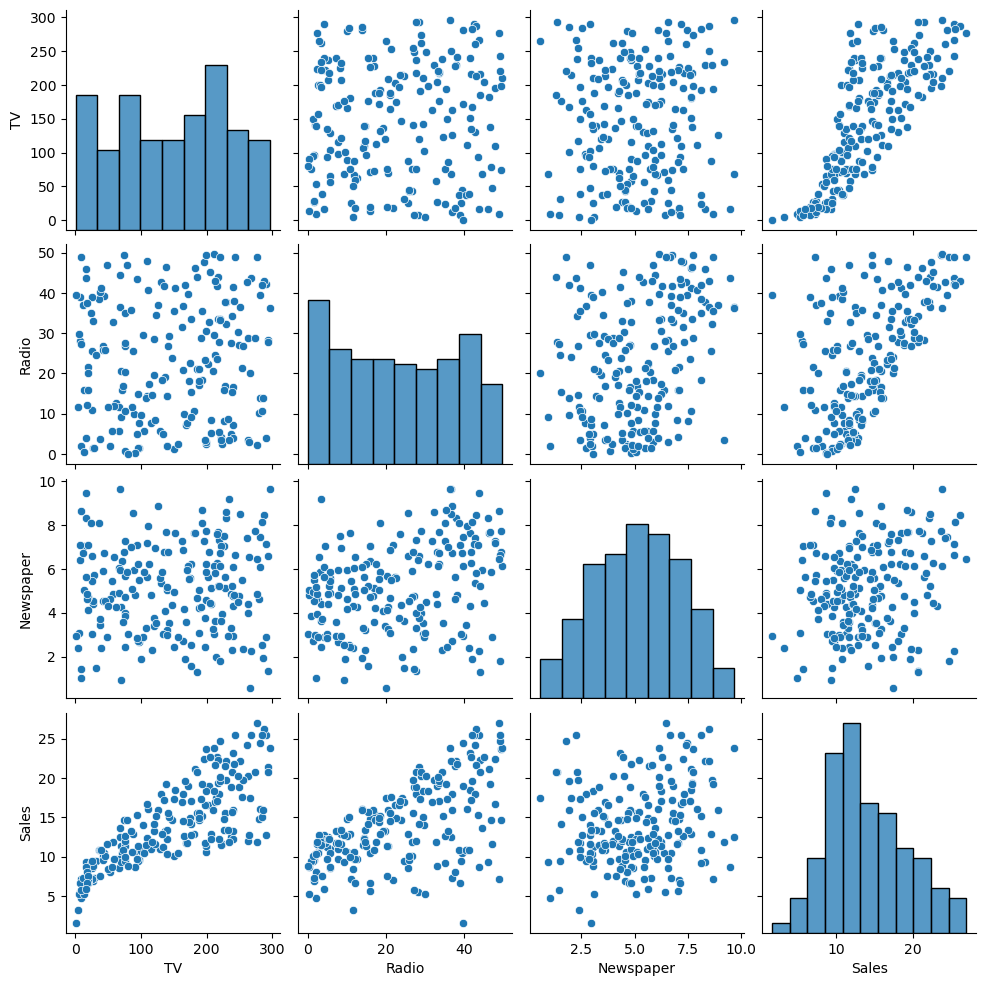

In [34]:
sns.pairplot(df)# to check linearity
# features and target are not linearly related so linearity fails.

<Axes: >

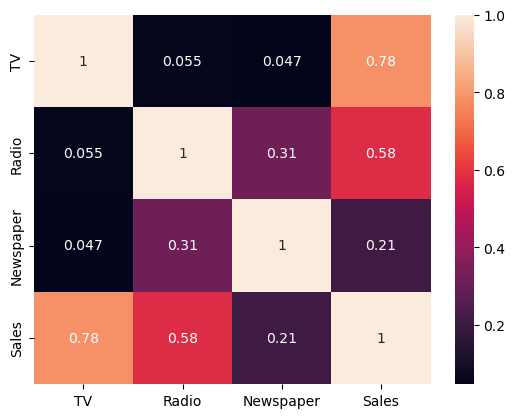

In [36]:
sns.heatmap(df[n_c].corr(),annot=True)
# multicollinearity not present if a threshold of +-0.5 is considered.
# so no multicollinearity

In [37]:
features=df.drop("Sales",axis=1)
target=df["Sales"]

In [38]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features

,TV,Radio,Newspaper
0,0.969852,0.981522,1.579479
1,-1.197376,1.082808,0.784690
2,-1.516155,1.528463,1.582458
3,0.052050,1.217855,1.247222
4,0.394182,-0.841614,1.243980
...,...,...,...
195,-1.270941,-1.321031,-0.703156
196,-0.617035,-1.240003,-1.133911
197,0.349810,-0.942899,-1.290701
198,1.594565,1.265121,1.489085


In [39]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=1,test_size=0.20)

In [40]:
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(160, 3) (160,)
(40, 3) (40,)


In [42]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(xtrain, ytrain) # training
ypred=reg.predict(xtest)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(ytest, ypred)
r2=r2_score(ytest,ypred)
print(f"mse : {mse}")
print(f"r2 (Model Accuarcy) : {r2}")

mse : 2.008477752231693
r2 (Model Accuarcy) : 0.8918672982921968


<Axes: ylabel='Sales'>

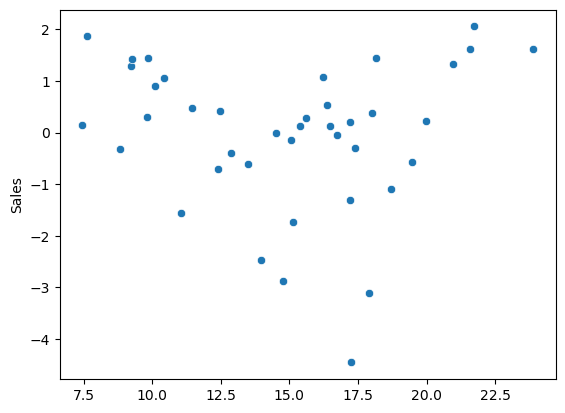

In [43]:
sns.scatterplot(x=ypred,y=(ytest-ypred)) # constant variance
# homoscedasticity property failed

<Axes: xlabel='Sales', ylabel='Density'>

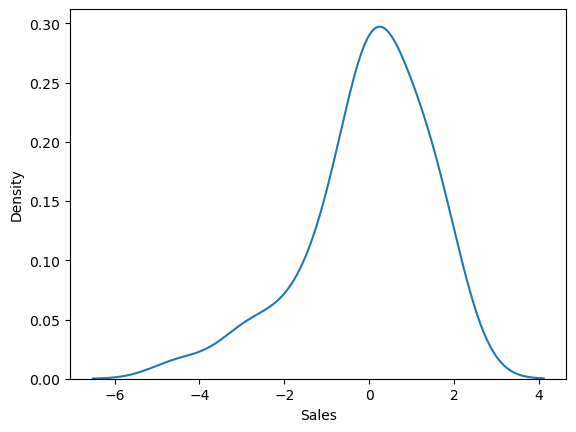

In [44]:
sns.kdeplot((ytest-ypred)) # normality of residuals
# normality also fails

In [45]:
# we will go with polynomial regression
from sklearn.preprocessing import PolynomialFeatures

In [47]:
# hypreparameter tuning
for i in range(2,8):
    poly=PolynomialFeatures(degree=i)
    xtrainp=poly.fit_transform(xtrain)
    xtestp=poly.transform(xtest)
    print(f"degree {i} : {xtrainp.shape}")
    lr=LinearRegression()
    lr.fit(xtrainp,ytrain)
    ypred=lr.predict(xtestp)
    mse=mean_squared_error(ytest,ypred)
    r2=r2_score(ytest,ypred)
    print(f"mse : {mse}")
    print(f"r2 (Model Accuarcy) : {r2}")

degree 2 : (160, 10)
mse : 0.21657770157647374
r2 (Model Accuarcy) : 0.9883398598888593
degree 3 : (160, 20)
mse : 0.191182122602592
r2 (Model Accuarcy) : 0.9897071105655613
degree 4 : (160, 35)
mse : 0.12567796513514096
r2 (Model Accuarcy) : 0.9932337324124693
degree 5 : (160, 56)
mse : 0.25430137436390154
r2 (Model Accuarcy) : 0.9863088876003621
degree 6 : (160, 84)
mse : 15.534282588011814
r2 (Model Accuarcy) : 0.16366315560739675
degree 7 : (160, 120)
mse : 435.5282851872794
r2 (Model Accuarcy) : -22.448031771892083


In [48]:
poly=PolynomialFeatures(degree=4)
xtrainp=poly.fit_transform(xtrain)
xtestp=poly.transform(xtest)
print(f"degree {i} : {xtrainp.shape}")
lr=LinearRegression()
lr.fit(xtrainp,ytrain)
ypred=lr.predict(xtestp)
mse=mean_squared_error(ytest,ypred)
r2=r2_score(ytest,ypred)
print(f"mse : {mse}")
print(f"r2 (Model Accuarcy) : {r2}")

degree 7 : (160, 35)
mse : 0.12567796513514096
r2 (Model Accuarcy) : 0.9932337324124693
